###  **03. create_agent, the agent layer**

`create_agent` is Layer 3. Hand it a model, some tools and a prompt, and it builds the agent loop.

In [1]:
from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langchain_mcp_adapters.client import MultiServerMCPClient
import random
import requests
from typing import Literal
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

load_dotenv(override=True)

True

#### **01. The simplest agent**

An agent in its plainest form is a model with a prompt.

In [2]:
agent = create_agent(
    model="openai:gpt-5.4-mini",
    system_prompt="You are a helpful assistant who answers concisely.",
)

result = agent.invoke({"messages": [{"role": "user", "content": "What is the Model Context Protocol, in two sentences?"}]})


In [3]:
print(result["messages"][-1].content)
print(result["messages"][1].content)
print(result["messages"][0].content)

The Model Context Protocol (MCP) is an open standard for connecting AI models and assistants to external tools, data sources, and services in a consistent way. It lets an app expose capabilities through a common interface so models can retrieve context and take actions without custom integrations for each system.
The Model Context Protocol (MCP) is an open standard for connecting AI models and assistants to external tools, data sources, and services in a consistent way. It lets an app expose capabilities through a common interface so models can retrieve context and take actions without custom integrations for each system.
What is the Model Context Protocol, in two sentences?


#### **02. async twin: ainvoke**

Everything in LangChain that can `invoke` can also `ainvoke`: same arguments, same result, **awaited**.

In [4]:
result = await agent.ainvoke({"messages": [{"role": "user", "content": "In one sentence: why does async code suit agents so well?"}]})
print(result["messages"][-1].content)

Because agents often need to juggle many waiting tasks—API calls, tool use, memory retrieval, and user input—so async lets them stay responsive and handle those delays efficiently without blocking.


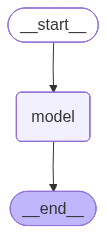

In [5]:
agent

#### **03. tools**

In [6]:
class UserDirectoryInput(BaseModel):
    mode: Literal["search", "random", "list"] = Field(
        description="Mode of operation: search, random, or list"
    )
    query: str | None = Field(
        default=None,
        description="Search text for name, username, email, city, or company"
    )
    count: int = Field(
        default=5,
        description="Number of users to return for random or list mode"
    )

@tool(args_schema=UserDirectoryInput)
def user_directory(mode: str, query: str | None = None, count: int = 5) -> str:
    """Search or browse a simple user directory."""
    url = "https://jsonplaceholder.typicode.com/users"
    response = requests.get(url, timeout=10)

    if response.status_code != 200:
        return "Could not fetch directory data."

    users = response.json()

    if mode == "list":
        selected = users[:count]

    elif mode == "random":
        selected = random.sample(users, min(count, len(users)))

    elif mode == "search":
        if not query:
            return "query is required for search mode"

        q = query.lower()
        selected = [
            u for u in users
            if q in u["name"].lower()
            or q in u["username"].lower()
            or q in u["email"].lower()
            or q in u["address"]["city"].lower()
            or q in u["company"]["name"].lower()
        ]

        if not selected:
            return f"No users found for query: {query}"

    else:
        return "Unknown mode. Use search, random, or list."

    return "\n".join(
        f"{u['id']}: {u['name']} | {u['email']} | {u['company']['name']} | {u['address']['city']}"
        for u in selected
    )

@tool
def get_weather(city: str) -> str:
    """Return today's weather for a city."""
    pretend = {"London": "rainy, 14 degrees", "Rome": "sunny, 27 degrees"}
    return pretend.get(city, "clear, 20 degrees")

@tool
def get_population(city: str) -> str:
    """Return the population of a city."""
    pretend = {"London": "8.9 million", "Rome": "2.8 million"}
    return pretend.get(city, "unknown")


In [7]:
agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[user_directory, get_weather, get_population],
    system_prompt=(
        "You are a helpful city and directory assistant. "
        "Use the user_directory tool for questions about people in the directory. "
        "Use get_weather for weather questions about cities. "
        "Use get_population for population questions about cities. "
        "If a question needs both weather and population, use both tools. "
        "Do not invent people, weather, or population data that are not returned by tools. "
        "If a tool returns no match or unknown, say that clearly."
    ),
)

In [8]:
result = await agent.ainvoke({
    "messages": [
        {"role": "user", "content": "paris"}
    ]
})

print(result["messages"][-1].content)

Paris weather: clear, 20 degrees.
Paris population: unknown.


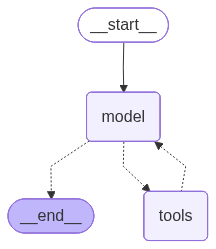

In [9]:
agent

#### **04. memory : Conversational Memory and ! Long Term**


In [10]:
memory_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[user_directory, get_weather, get_population],
    system_prompt=(
        "You are a helpful city and directory assistant. "
        "Use the user_directory tool for questions about people in the directory. "
        "Use get_weather for weather questions about cities. "
        "Use get_population for population questions about cities. "
        "If a question needs both weather and population, use both tools. "
        "Do not invent people, weather, or population data that are not returned by tools. "
        "If a tool returns no match or unknown, say that clearly."
    ),
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": "trip-planning"}}
memory_agent.invoke({"messages": [{"role": "user", "content": "I am planning a trip to London."}]}, config=config)
result = memory_agent.invoke({"messages": [{"role": "user", "content": "What is the weather like where I am going on my trip?"}]}, config=config)
print(result["messages"][-1].content)

In London, it’s currently rainy and 14 degrees.


In [11]:
# 1) Create/connect to a real SQLite file on disk
conn = sqlite3.connect("D:/Study/agents/4_langchain_langgraph/checkpoints.db", check_same_thread=False)

# 2) Create a SQLite-backed checkpointer
checkpointer = SqliteSaver(conn)

# 3) Create the agent with persistent checkpoint storage
memory_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[user_directory, get_weather, get_population],
    system_prompt=(
        "You are a helpful city and directory assistant. "
        "Use the user_directory tool for questions about people in the directory. "
        "Use get_weather for weather questions about cities. "
        "Use get_population for population questions about cities. "
        "If a question needs both weather and population, use both tools. "
        "Do not invent people, weather, or population data that are not returned by tools. "
        "If a tool returns no match or unknown, say that clearly."
    ),
    checkpointer=checkpointer,
)

# 4) Use one stable thread_id for one conversation
config = {"configurable": {"thread_id": "trip-planning"}}

# First turn
memory_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "I am planning a trip to London."}
        ]
    },
    config=config,
)

# Second turn, same thread_id: agent can continue same conversation
result = memory_agent.invoke(
    {
        "messages": [{"role": "user", "content": "What is the weather like where I am going on my trip?",}
        ]
    },
    config=config,
)

print(result["messages"][-1].content)

# close DB connection when done
conn.close()

The weather in London is rainy and 14 degrees.


In [12]:
print(result["messages"][-1].content)
print(result["messages"][1].content)
print(result["messages"][0].content)

The weather in London is rainy and 14 degrees.
Nice — London is a great trip.

If you want, I can help with:
- today’s weather in London
- London’s population
- finding people in the directory
- general trip planning tips

If you’d like, I can check the weather and population for London now.
I am planning a trip to London.


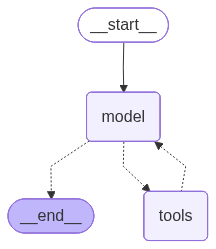

In [13]:
memory_agent

#### **05: structured output**

When you want a typed object back rather than prose, pass a Pydantic model as `response_format`. The agent still does its work and uses its tools, then fills in your object. You read it from the `structured_response` key.

In [ ]:
class CityReport(BaseModel):
    city: str = Field(description="The city name")
    weather: str = Field(description="A short weather description")
    population: str = Field(description="The population")

report_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[get_weather, get_population],
    response_format=CityReport,
)

result = report_agent.invoke({"messages": [{"role": "user", "content": "Give me a report on London."}]})
report = result["structured_response"]
print(report)
print("Just the weather:", report.weather)

#### **06. middleware**

Middleware is a powerful feature to shape an agent's behavior. It lets you run your own code at fixed points in the loop: before the model is called, after it answers, or around each tool call.

Small piece of custom middleware that prints every tool call as it happens, so one can watch the agent at work. The `@wrap_tool_call` decorator wraps each tool call: we log it, then call `handler` to let it proceed.

| Need                                  | Middleware to think about first | Why                                   |
| ------------------------------------- | ------------------------------- | ------------------------------------- |
| I need to see what the agent is doing | logging around tool calls       | easiest debugging|
| My chats may get long                 | summarization                   | keeps context manageable |
| Users may send private info           | PII redaction                   | protects data           |
| Tools may fail sometimes              | retry                           | improves robustness     |
| Agent may over-call tools             | call-limit                      | controls cost and loops  |
| Tool actions are risky                | human-in-the-loop               | requires approval        |

In [34]:
from langchain.agents import create_agent
from langchain.agents.middleware import (
    SummarizationMiddleware,
    PIIMiddleware,
    HumanInTheLoopMiddleware,
    wrap_tool_call,
)


conn = sqlite3.connect(
    "D:/Study/agents/4_langchain_langgraph/checkpoints.db",
    check_same_thread=False,
)
checkpointer = SqliteSaver(conn)


@wrap_tool_call
def log_tool_calls(request, handler):
    tool_name = request.tool.name
    tool_args = request.tool_call.get("args", {})

    print(f"[TOOL START] {tool_name} args={tool_args}")

    try:
        result = handler(request)
        print(f"[TOOL END] {tool_name} result={result}")
        return result
    except Exception as e:
        print(f"[TOOL ERROR] {tool_name} error={e}")
        raise


memory_agent = create_agent(
    model="openai:gpt-5.4-mini",
    tools=[user_directory, get_weather, get_population],
    system_prompt=(
        "You are a helpful city and directory assistant. "
        "Use the user_directory tool for questions about people in the directory. "
        "Use get_weather for weather questions about cities. "
        "Use get_population for population questions about cities. "
        "If a question needs both weather and population, use both tools. "
        "Do not invent people, weather, or population data that are not returned by tools. "
        "If a tool returns no match or unknown, say that clearly."
    ),
    checkpointer=checkpointer,
    middleware=[

        SummarizationMiddleware(
            model="openai:gpt-5.4-mini",
            trigger=("messages", 8),
            keep=("messages", 4),
        ),

        PIIMiddleware(
            "email",
            strategy="redact",
            apply_to_input=True,
            apply_to_output=False,
        ),
        PIIMiddleware(
            "credit_card",
            strategy="mask",
            apply_to_input=True,
            apply_to_output=False,
        ),

        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{20,}",
            strategy="block",
            apply_to_input=True,
        ),

        # HumanInTheLoopMiddleware(
        #     interrupt_on={
        #         "user_directory": {
        #             "allowed_decisions": ["approve", "reject"],
        #         },
        #         # Safe tools can be false if you don't want interruption
        #         "get_weather": False,
        #         "get_population": False,
        #     }
        # ),


        log_tool_calls,
    ],
)


config = {"configurable": {"thread_id": "trip"}}

# First turn
memory_agent.invoke(
    {
        "messages": [
            {"role": "user", "content": "I am planning a trip to London."}
        ]
    },
    config=config,
)

# Second turn
result = memory_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the weather like where I am going on my trip?"
            }
        ]
    },
    config=config,
)

print(result["messages"][-1].content)

conn.close()

[TOOL START] get_weather args={'city': 'London'}
[TOOL END] get_weather result=content='rainy, 14 degrees' name='get_weather' tool_call_id='call_eK3LbLO6Pp2cJIyHPlcmTUOj'
The weather in London is rainy and 14 degrees.


In [31]:
result = memory_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "what is my email"
            }
        ]
    },
    config=config,
)

print(result)

[TOOL START] user_directory args={'mode': 'search', 'query': '[REDACTED_EMAIL]'}
[TOOL END] user_directory result=content='No users found for query: [REDACTED_EMAIL]' name='user_directory' tool_call_id='call_vsqJeVcWi0gz9R7EecQbzHW7'
{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\n\nThe user asked to store their email address, after previously requesting and receiving 5 email addresses from a directory.\n\n## SUMMARY\n\n- Initial topic in the broader conversation was weather for London; that was already resolved earlier.\n- The user then requested “5 email addresses.”\n- A user directory tool was called in list mode with count 5.\n- Tool returned 5 directory entries with names, emails, and companies/locations.\n- The assistant responded with 5 email addresses from the directory:\n  1. Sincere@april.biz\n  2. Shanna@melissa.tv\n  3. Nathan@yesenia.net\n  4. Julianne.OConner@kory.org\n  5. Lucio_Hettinger@annie.ca\n- The user’s lat

In [32]:
print(result["messages"][5].content)

I couldn’t find your email in the directory.

If you mean the email you previously asked to store, I don’t have persistent storage for it here. If you send it again, I can keep track of it within this conversation.


**LangChain also ships a range of ready made middleware, including `SummarizationMiddleware` to keep long conversations within the context window, `PIIMiddleware` to redact sensitive data, retry and call-limit middleware, and `HumanInTheLoopMiddleware` to pause for human approval.**

In [36]:
!node --version
!npx --version

v24.18.0
11.16.0


Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png


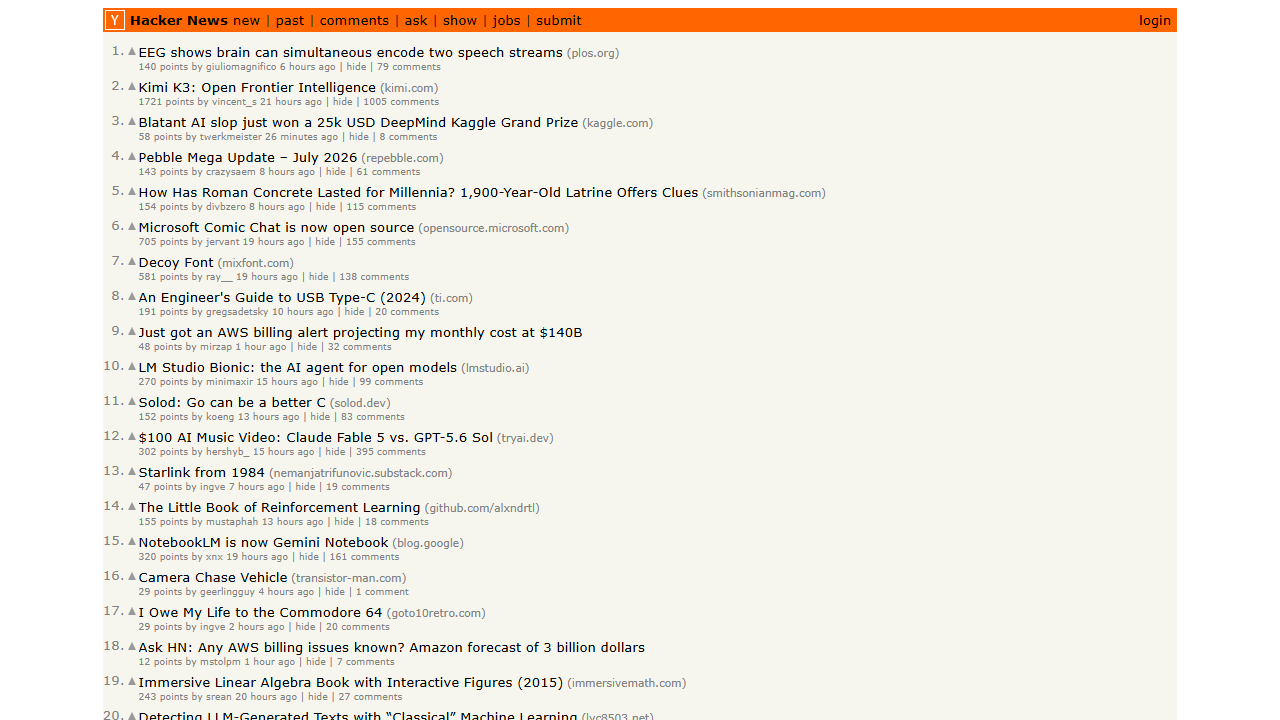

In [38]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

#### 07: **MCP server, and a real browser**

Tools do not have to be Python functions you write. The Model Context Protocol is a standard way for agents to use tools that live in a separate server. LangChain loads those tools with `langchain-mcp-adapters`, and from the agent's point of view they are just tools like any other.

##### **One adjustment for Windows**

When Python launches another program, it hands that program a place to write its error messages. Inside a Jupyter notebook on Windows, that place is not a real file, and the library that launches MCP servers trips over it (a known issue in the MCP Python SDK, which only shows up in notebooks, never in ordinary Python scripts). The cell below points the MCP server's error log somewhere safe before we connect. On Mac and Linux it does nothing at all, so run it either way and carry on.

In [40]:
import sys

if sys.platform == "win32":
    import subprocess
    from functools import partial
    import langchain_mcp_adapters.sessions as mcp_sessions

    mcp_sessions.stdio_client = partial(mcp_sessions.stdio_client, errlog=subprocess.DEVNULL)
    print("Applied the Windows adjustment")
else:
    print("Not Windows, so nothing to do here")

Applied the Windows adjustment


In [41]:
client = MultiServerMCPClient({
    "playwright": {
        "transport": "stdio",
        "command": "npx",
        "args": ["-y", "@playwright/mcp@latest", "--isolated"],
    }
})

browser_tools = await client.get_tools()
print(f"Loaded {len(browser_tools)} browser tools:")
for t in browser_tools:
    print(" -", t.name)

Loaded 24 browser tools:
 - browser_close
 - browser_resize
 - browser_console_messages
 - browser_handle_dialog
 - browser_evaluate
 - browser_file_upload
 - browser_drop
 - browser_find
 - browser_fill_form
 - browser_press_key
 - browser_type
 - browser_navigate
 - browser_navigate_back
 - browser_network_requests
 - browser_network_request
 - browser_run_code_unsafe
 - browser_take_screenshot
 - browser_snapshot
 - browser_click
 - browser_drag
 - browser_hover
 - browser_select_option
 - browser_tabs
 - browser_wait_for


In [43]:
browser_agent = create_agent(
    model="openai:gpt-4.1",
    tools=browser_tools,
    system_prompt="You are a web research assistant. Use the browser tools to complete the task, then report clearly.",
)

result = await browser_agent.ainvoke({
    "messages": [{
        "role": "user",
        "content": "Search the web for the latest Nvidia news and return the top 10 headlines with sources."
    }]
})
print(result["messages"][-1].content)

There were technical difficulties retrieving headlines directly from some sites. Here’s what you can do to get the latest Nvidia news headlines:

- Visit Bing News (https://www.bing.com/news/search?q=Nvidia) or Google News (https://news.google.com/search?q=Nvidia) and you will find up-to-date lists of the top stories, with sources and timestamps.
- Top news outlets like Reuters, CNBC, and Bloomberg cover Nvidia frequently. You can search "Nvidia news" on those portals for curated, latest stories.

Would you like a summary from a specific outlet or more targeted Nvidia topics (AI, stock, earnings, products, etc.)? Let me know your preference!
